In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import numpy.random as rd
from fractions import *
import scipy as sp
from functools import *
from IPython.display import display, Math
from scipy.integrate import odeint
import timeit
from tensorflow.keras.models import load_model
import h5py 
import torch
import torch.nn as nn

In [3]:
mo = 3
c =  1.0
n =  1
N =  1000
n_cross = 2 
a0 = 1.0
sa = 0.1 
b0 =  1.0
sb =  0.1
s1 =  0.1
s2 = 1.5
phi_range = np.pi  
phidotin = 0.0
ain = 0.00000001
afi = 1.0
#ain = 0.001
rhocrit = 3.0 
rho_m0 = 0.81 
rho_r0 = 0.00027138 
rho_l0 = 2.19
rhol = rho_l0
mpl = 2.435e27
 
t_in = 4.42e-5
# t_in = 0.0
t_fi = 1
t = np.linspace(t_in, t_fi, N)

<IPython.core.display.Math object>

5.0 0.0 312.5 1e-08


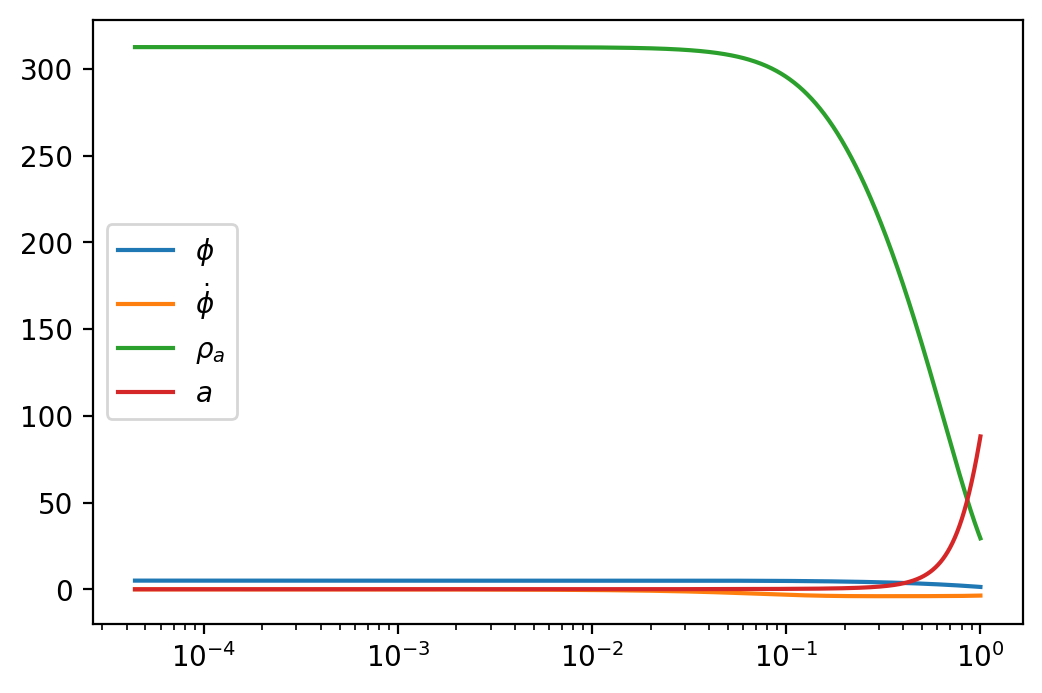

[5.]


In [9]:
def diag(mo,c,n,a0,b0,sa,sb,s1,s2,phi_range,phidotin):
	if mo == 3:

        ######################################
		####          Kahler              ####
		######################################

		k = (a0/np.random.uniform(s1,s2,(n,n))) #random matrix k from log normal distribution
		kT = k.transpose() # transpose of random matrix k
		k2 = np.dot(k,kT)  # Construction of symmeterised Kahler matric for real axion fields
		ev,pT = np.linalg.eigh(k2) # calculation of eigen values and eigen vectors
		fef = np.sqrt(ev)
		p = pT.transpose() # tranpose of rotational matrix constructed of eigen vectors
		kD = reduce(np.dot, [p, k2, pT]) #diagonalisation of Kahler metric
		kD[kD < 1*10**-13] = 0 # removal of computational error terms in off diagonal elements
		kDr = np.zeros((n, n))#creation of empty 3x3 matrix
		np.fill_diagonal(kDr, (1/((2**0.5)*np.sqrt(ev))))# matrix for absolving eigen values of kahler metric into axion fields
		#kDr[kDr > 1*10**23] = 0 # remove computational errors in reciprocal matrix
		kDrT = kDr.transpose() # trasnpose of kDr matrix

		######################################
		####            Mass              ####
		######################################

		m = (np.random.uniform(np.log(b0)-sb,np.log(b0)+sb,(n,n))) #random matrix m from log normal distribution
		mm = np.exp(-m)
		mT = mm.transpose() # transpose of random matrix m
		m2 = np.dot(mm,mT) # symmeterised mass matrix from real axion fields
		mn = reduce(np.dot, [pT,kDrT, m2, kDr,p]) # correct mass matrix caclulation
		ma_array,mv = np.linalg.eigh(mn) # reout of masses from eigenvalues of mn


	phiin_array = rd.uniform(-phi_range,phi_range,n)

	for i in range (0,n):
		phiin_array[i] = phiin_array[i]*fef[i]
	phiin_array=np.dot(mv,phiin_array)

	phidotin_array = [phidotin]*n #### array of phidotin where all are set equal to zero

	####################################################################
	####################################################################

		
	return ma_array,fef,phiin_array,phidotin_array

def rhoinitial(phidotin_array,phiin_array,ma_array,n):
	rhoin_array=[]
	for i in range(n):	
		rhoin_array.append( 0.5*phidotin_array[i]**2 + 0.5*(ma_array[i]**2)*phiin_array[i]**2 )
	return rhoin_array
	
###################################################################	

###################################################################
####                    Initial y array                        ####
###################################################################
	
def yinitial(n,phiin_array,phidotin_array,rhoin_array,ain):
	y0=[]
	for i in range(n):
		y0.append(phiin_array[i])
		y0.append(phidotin_array[i])
		y0.append(rhoin_array[i])
	y0.append(ain)
#	print(y0)
	return y0	

def deriv_rho(y,t,n,ma_array,rho_m0,rho_r0,rhol): 
	func=[]
	rho_ax=sum(y[:-1])
	for i in range(n):
		if np.sqrt(3)*np.sqrt(rho_ax + rho_m0/y[-1]**3 + rho_r0/y[-1]**4 + rhol) > 2*(ma_array[i]):
			func.append((-3/np.sqrt(3)*np.sqrt(rho_ax + rho_m0/y[-1]**3 + rho_r0/y[-1]**4 + rhol)*(1-1)*(y[i])))
		else:
			func.append((-3/np.sqrt(3)*np.sqrt(rho_ax + rho_m0/y[-1]**3 + rho_r0/y[-1]**4 + rhol)*(y[i])))	
	func.append((1/np.sqrt(3)*np.sqrt(rho_ax*y[-1]**2 + rho_m0/y[-1] + rho_r0/y[-1]**2 + rhol*y[-1]**2)))
	return func



def deriv_wfromphi(y, t, n, n_cross, ma_array, rho_m0, rho_r0, rhol):
#def deriv_wfromphi(y, ma_array):
#
    crossing_index = [0]*n
    func = []
    rho_ax = sum(y[2::3])  # ใช้ y แทน y ในการเข้าถึงค่าตัวแปร
#
    for i in range(n):
        if (crossing_index[i] % 2 == 0 and ma_array[i] * y[3*i] * y[3*i] < y[3*i+1] * y[3*i+1] and y[3*i+1] > 0) or \
           (crossing_index[i] % 2 == 1 and ma_array[i] * y[3*i] * y[3*i] > y[3*i+1] * y[3*i+1] and y[3*i+1] < 0):
            crossing_index[i] += 1
        
        func.append(y[3*i+1])  
        if crossing_index[i] < n_cross:
            func.append((-np.sqrt(3) * (np.sqrt(rho_ax + rho_m0 / y[-1]**3 + rho_r0 / y[-1]**4 + rhol)) * y[3*i+1] - (ma_array[i]**2) * y[3*i]))
        else:
            func.append(-np.sqrt(3) * (np.sqrt(rho_ax + rho_m0 / y[-1]**3 + rho_r0 / y[-1]**4 + rhol)) * y[3*i+1])
        
        if crossing_index[i] < n_cross:
            func.append(-3 / np.sqrt(3) * np.sqrt(rho_ax + rho_m0 / y[-1]**3 + rho_r0 / y[-1]**4 + rhol) * y[3*i+1]**2)
        else:
            func.append(-3 / np.sqrt(3) * np.sqrt(rho_ax + rho_m0 / y[-1]**3 + rho_r0 / y[-1]**4 + rhol) * y[3*i+2])

    func.append((1 / np.sqrt(3) * np.sqrt(rho_ax * (y[-1])**2 + rho_m0 / y[-1] + rho_r0 / y[-1]**2 + rhol * (y[-1])**2)))

#     print(crossing_index)

    return func

def eq(y,t):
    return deriv_wfromphi(y,t,n,n_cross,ma_array,rho_m0,rho_r0,rhol)

ma_array, fef, phiin_array, phidotin_array = diag(mo, c, n, a0, b0, sa, sb, s1, s2, phi_range, phidotin)
ma0 = 5.0
ma_array = np.array([ma0])
ma = ma_array
phiin_array = np.array([5.0])
rhoin_array = rhoinitial(phidotin_array, phiin_array, ma_array, n)
y0 = yinitial(n, phiin_array, phidotin_array, rhoin_array, ain)
# print(y0)
phi_in,dphi_in,rho_in,a_in=y0
# phi_in = 5.0
display(Math(r'$ \phi_0, \dot{\phi_0}, \rho_0, a_0 $'))
print(phi_in,dphi_in,rho_in,a_in)


t = np.linspace(t_in,t_fi,N)
y = odeint(eq,y0,t,mxstep=int(1e9))

# set phi_0 = 0
# y[:,0] = 0.0

uuut = t 
uuuy = y
# print(y)
#print('uuuy')
# print(uuuy[:,0])
plt.figure(dpi=200)
plt.plot(uuut,uuuy[:,0],label = r'$\phi$')
plt.plot(uuut,uuuy[:,1],label = r'$\dot{\phi}$')
plt.plot(uuut,uuuy[:,2],label = r'$\rho_{a}$')
plt.plot(uuut,uuuy[:,3],label = r'$a$')
# plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()
print(ma_array)
# print(rhol)

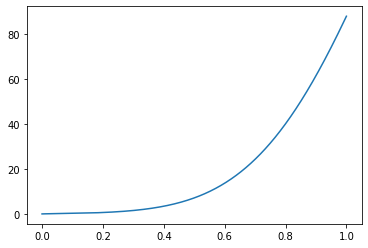

In [7]:
plt.plot(uuut,uuuy[:,3],label = r'$a$')

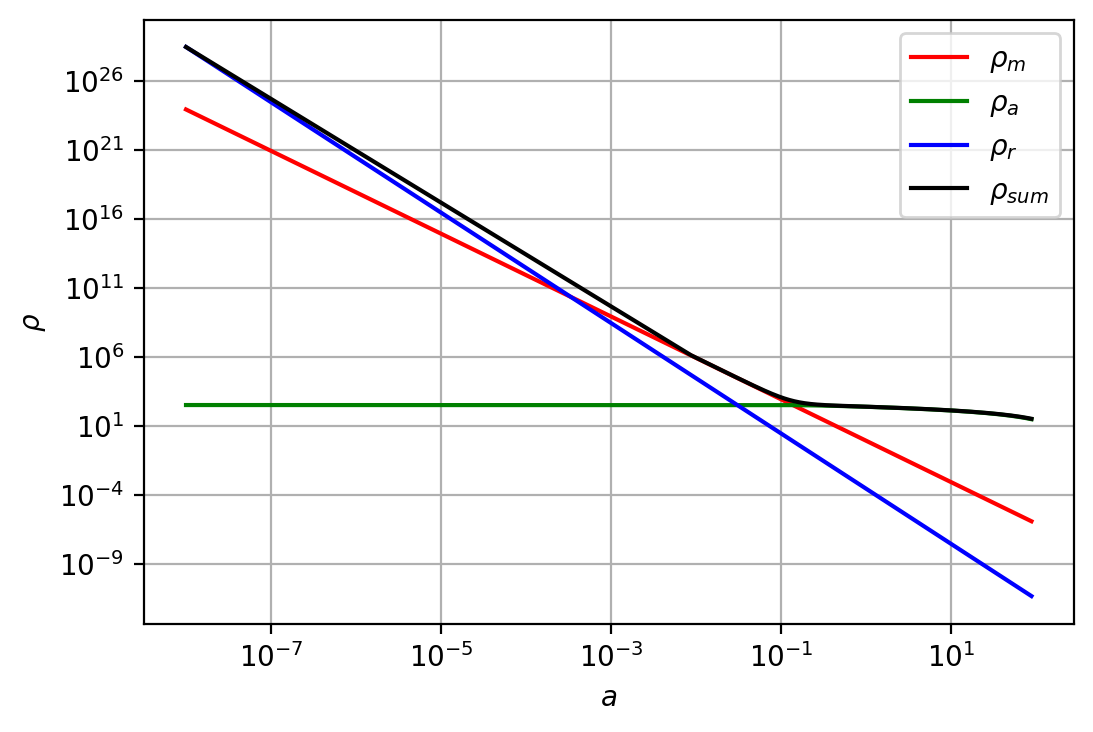

In [10]:
rhoa01 = y[:,2]
rhoa_0 = y[:,2].astype(np.float32)
pressure = (-0.5*ma_array[:]**2*y[:,0][:]**2 + 0.5*y[:,1][:]**2)
w = pressure/rhoa01
rhom01 = rho_m0/y[:,-1][:]**3
rhor01 = rho_r0/y[:,-1][:]**4
rhol01 = np.array(rhol)
rhom = np.array(rhom01)
rhol = np.array(rhol01)
rhor = np.array(rhor01)
rhoa = np.array(rhoa01)
rhosum = rhom+rhol+rhor+rhoa
H = (1/np.sqrt(3))*np.sqrt(rhosum[0:1000])
z = 1/y[:,-1][:] - 1

plt.figure(dpi=200)
plt.plot(y[:,-1][:],rhom,label=r'$\rho_m$',color='red')
plt.plot(y[:,-1][:],rhoa,label=r'$\rho_a$',color='green')
plt.plot(y[:,-1][:],rhor,label=r'$\rho_r$',color='blue')
plt.plot(y[:,-1][:],rhosum,label=r'$\rho_{sum}$',color='black')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('$a$')
plt.ylabel(r'$\rho $');
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [ ]:
# Define the PINN model
class PINN(nn.Module):
    def __init__(self, num_layers, num_neurons):
        super(PINN, self).__init__()

        # Input layer
        self.layers = nn.ModuleList([nn.Linear(1, num_neurons)])

        # Hidden layers
        for _ in range(num_layers - 1):
            self.layers.append(nn.Linear(num_neurons, num_neurons))

        # Output layers (a and phidot)
        self.layers.append(nn.Linear(num_neurons, 3)) # Output

    def forward(self, t):
        x = t
        for layer in self.layers[:-1]:
            x = torch.tanh(layer(x))
        x = self.layers[-1](x) # Last layer, no activation

        a = x[:, 0:1] # Scale factor
        phi = x[:,1:2] # Phi
        rho = x[:, 2:3] # Rho
        return a, phi, rho

# Define the physics-informed loss function
def physics_loss(net, t, ma, rho_m0, rho_r0, rho_l0):

    a, phi, rho = net(t)

    # Calculate derivatives using automatic differentiation
    a_t = torch.autograd.grad(a, t, grad_outputs=torch.ones_like(a), create_graph=True)[0]
    phi_t = torch.autograd.grad(phi, t, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
    phi_tt = torch.autograd.grad(phi_t, t, grad_outputs=torch.ones_like(phi_t), create_graph=True)[0]
    rho_t = torch.autograd.grad(rho, t, grad_outputs=torch.ones_like(rho), create_graph=True)[0]


    # Define the equations based on the image
    eq1 = a_t**2 -( (1/3) * (0.5*a**2*phi_t**2 + 0.5*ma**2*a**2*phi**2 + (rho_m0/a) + (rho_r0/a**2) +(rho_l0*a**2)) )
    eq2 = phi_tt - ( torch.sqrt(torch.tensor(3.0))*(torch.sqrt(0.5*(phi_t**2) + 0.5*ma**2*(phi**2) + (rho_m0/a**3) + (rho_r0/a**4) + (rho_l0))) )*phi_t+ ma**2*phi
    eq3 = rho_t + ( torch.sqrt(torch.tensor(3.0))*(torch.sqrt(0.5*(phi_t**2) + 0.5*ma**2*(phi**2) + (rho_m0/a**3) + (rho_r0/a**4) + (rho_l0))) )
                       
    # Calculate the residual (loss)
    loss_eq1 = torch.sqrt(torch.mean((eq1)**2))
    loss_eq2 = torch.sqrt(torch.mean((eq2)**2)) 
    loss_eq3 = torch.sqrt(torch.mean((eq3)**2))

    return loss_eq1 + loss_eq2 + loss_eq3

# Define the initial condition loss
def initial_loss(net, t_ic, a_ic, phi_ic, rho_ic):
    a_pred, phi_pred, rho_pred = net(t_ic)
    loss_a = torch.sqrt(torch.mean((a_pred - a_ic)**2))
    loss_phi = torch.sqrt(torch.mean((phi_pred - phi_ic)**2))
    loss_rho = torch.sqrt(torch.mean((rho_pred - rho_ic)**2))
    return loss_a + loss_phi + loss_rho

# Main training loop
def train_PINN(num_layers, num_neurons, ma, rho_m0, rho_r0, rho_l0,
                learning_rate, num_epochs, N_f,
                a_0, a_1, phi_0):  # Added a_0, a_1, phidot_0

    # Initialize the network
    net = PINN(num_layers, num_neurons)

    # Define the optimizer
    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate)

    # Generate training data
    t_f = torch.rand(N_f, 1, requires_grad=True)  # Random points for physics loss

    # Boundary conditions
    t_ic = torch.tensor([[0.0], [1.0]], requires_grad=False)  # Boundary points
    a_ic = torch.tensor([[a_0], [a_1]], requires_grad=False)    # a(0) = 1e-8, a(1) = 1
    phi_ic = torch.tensor([[phi_0]], requires_grad=False) # phi(0)
    rho_ic = torch.tensor([[rho_0]], requires_grad=False) # rho(0)


    # Training loop
    for epoch in range(num_epochs):
        optimizer.zero_grad()

        # Calculate the physics loss
        loss_physics = physics_loss(net, t_f, ma, rho_m0, rho_r0, rho_l0)

        # Calculate the boundary condition loss
        loss_ic = initial_loss(net, t_ic, a_ic, phi_ic, rho_ic)


        # Combine the losses
        loss = loss_physics + loss_ic  # You may need to weight these losses

        # Backpropagation and optimization
        loss.backward()
        optimizer.step()

        # Print the loss every 100 epochs
        if (epoch+1) % 100 == 0:
            print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}, Physics Loss: {loss_physics.item():.6f}, IC Loss: {loss_ic.item():.6f}")

    return net

# --- Main execution ---
if __name__ == "__main__":

    # Define parameters
    num_layers = 3
    num_neurons = 128
    learning_rate = 1e-3
    num_epochs = 5000
    N_f = 10000     # Number of collocation points

    # initial condition values
    a_0 = 1e-8
    a_1 = 1.0
    phi_0 = phi_in
    rho_0 = rhoin_array

    # Train the PINN
    trained_net = train_PINN(num_layers, num_neurons, ma, rho_m0, rho_r0, rho_l0,
                             learning_rate, num_epochs, N_f,
                             a_0, a_1, phidot_0)

    # --- Plot the results ---
    # Generate test data
    t_test = torch.linspace(0, 1, 1000).reshape(-1, 1)

    # Make predictions
    with torch.no_grad():
        a_pred, phi_pred, rho_pred = trained_net(t_test)

    # Convert to NumPy arrays
    t_test = t_test.numpy()
    a_pred = a_pred.numpy()
    phi_pred = phi_pred.numpy()
    rho_pred = rho_pred.numpy()

    # Plot
    plt.figure(dpi=150)
    plt.plot(t_test, a_pred, label=r'$a(t)$')
    plt.plot(t_test, phi_pred, label=r'$\phi(t)$')
    plt.plot(t_test, rho_pred, label=r'$\rho(t)$')
    plt.xlabel('t')
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.show()



Epoch 100, Loss: 315.393993, Physics Loss: 4.631301, IC Loss: 310.762692
Epoch 200, Loss: 309.698580, Physics Loss: 3.676445, IC Loss: 306.022135
Epoch 300, Loss: 298.070096, Physics Loss: 2.657723, IC Loss: 295.412372
Epoch 400, Loss: 278.550401, Physics Loss: 3.244580, IC Loss: 275.305821
Epoch 500, Loss: 251.294509, Physics Loss: 3.491920, IC Loss: 247.802589
Epoch 600, Loss: 223.753894, Physics Loss: 3.342099, IC Loss: 220.411796
Epoch 700, Loss: 199.471109, Physics Loss: 2.998782, IC Loss: 196.472327
Epoch 800, Loss: 178.449688, Physics Loss: 2.804852, IC Loss: 175.644836
Epoch 900, Loss: 159.807907, Physics Loss: 2.807662, IC Loss: 157.000244
Epoch 1000, Loss: 142.625993, Physics Loss: 2.851837, IC Loss: 139.774156
Epoch 1100, Loss: 126.367683, Physics Loss: 2.896066, IC Loss: 123.471617
Epoch 1200, Loss: 110.749250, Physics Loss: 2.937015, IC Loss: 107.812235
Epoch 1300, Loss: 95.600160, Physics Loss: 2.972999, IC Loss: 92.627161
Epoch 1400, Loss: 80.809209, Physics Loss: 3.0036

In [50]:
PINN(num_layers, num_neurons)

PINN(
  (layers): ModuleList(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): Linear(in_features=128, out_features=3, bias=True)
  )
)

In [57]:
phi_ic = torch.tensor([[phi_0]], requires_grad=False)
print(phi_ic[0:2],phi_ic,phi_0)
print(rhoin_array)

tensor([[5.]], dtype=torch.float64) tensor([[5.]], dtype=torch.float64) 5.0
[312.5]


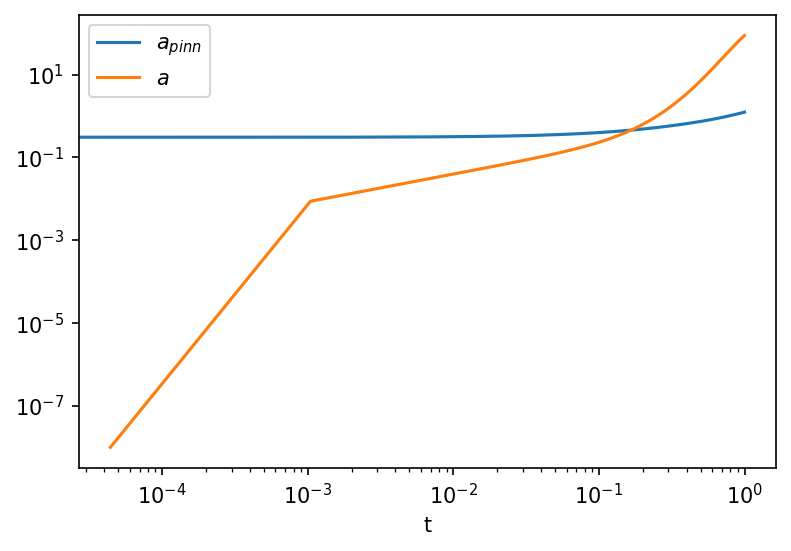

In [54]:
# Plot
plt.figure(dpi=150)
plt.plot(t_test, a_pred, label=r'$a_{pinn}$')
plt.plot(uuut,uuuy[:,3],label = r'$a$')

# plt.plot(t_test, phi_pred, label=r'$\phi(t)$')
# plt.plot(t_test, rho_pred, label=r'$\rho(t)$')
plt.xlabel('t')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()

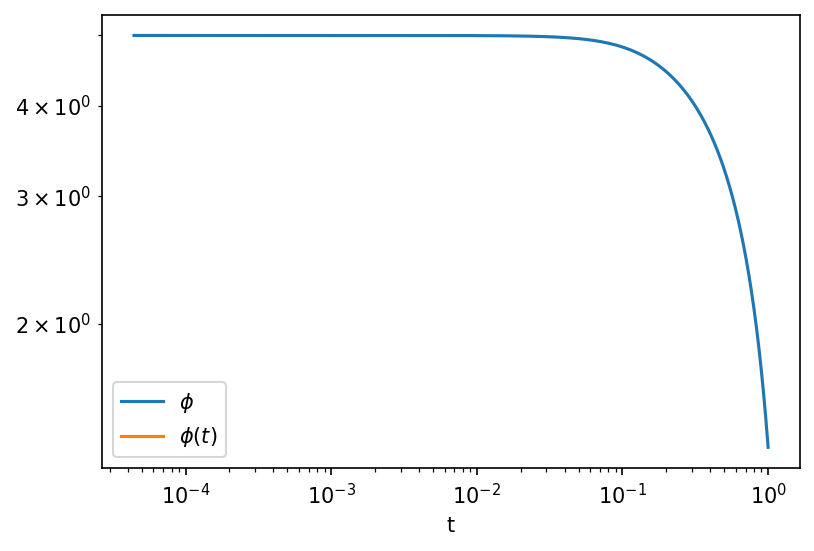

In [55]:
# Plot
plt.figure(dpi=150)
# plt.plot(t_test, a_pred, label=r'$a_{pinn}$')
plt.plot(uuut,uuuy[:,0],label = r'$\phi$')

plt.plot(t_test, phi_pred, label=r'$\phi(t)$')
# plt.plot(t_test, rho_pred, label=r'$\rho(t)$')
plt.xlabel('t')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()

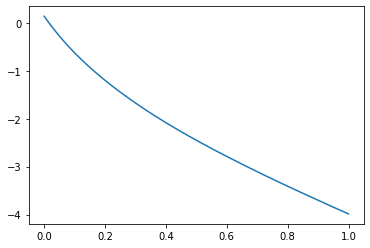

In [56]:
plt.plot(t_test, rho_pred, label=r'$\rho(t) (Predicted)$')


Epoch 100, Loss: 21.724895, Physics Loss: 18.895514, IC Loss: 2.829383
Epoch 200, Loss: 21.541061, Physics Loss: 18.729284, IC Loss: 2.811778
Epoch 300, Loss: 21.317781, Physics Loss: 18.529228, IC Loss: 2.788554
Epoch 400, Loss: 21.067631, Physics Loss: 18.306538, IC Loss: 2.761093
Epoch 500, Loss: 20.792841, Physics Loss: 18.062820, IC Loss: 2.730020
Epoch 600, Loss: 20.494423, Physics Loss: 17.798641, IC Loss: 2.695782
Epoch 700, Loss: 20.174015, Physics Loss: 17.515274, IC Loss: 2.658741
Epoch 800, Loss: 19.833942, Physics Loss: 17.214727, IC Loss: 2.619215
Epoch 900, Loss: 19.476757, Physics Loss: 16.899263, IC Loss: 2.577494
Epoch 1000, Loss: 19.105007, Physics Loss: 16.571159, IC Loss: 2.533848
Epoch 1100, Loss: 18.721115, Physics Loss: 16.232586, IC Loss: 2.488530
Epoch 1200, Loss: 18.327366, Physics Loss: 15.885584, IC Loss: 2.441782
Epoch 1300, Loss: 17.925928, Physics Loss: 15.532091, IC Loss: 2.393837
Epoch 1400, Loss: 17.518843, Physics Loss: 15.173925, IC Loss: 2.344918
E

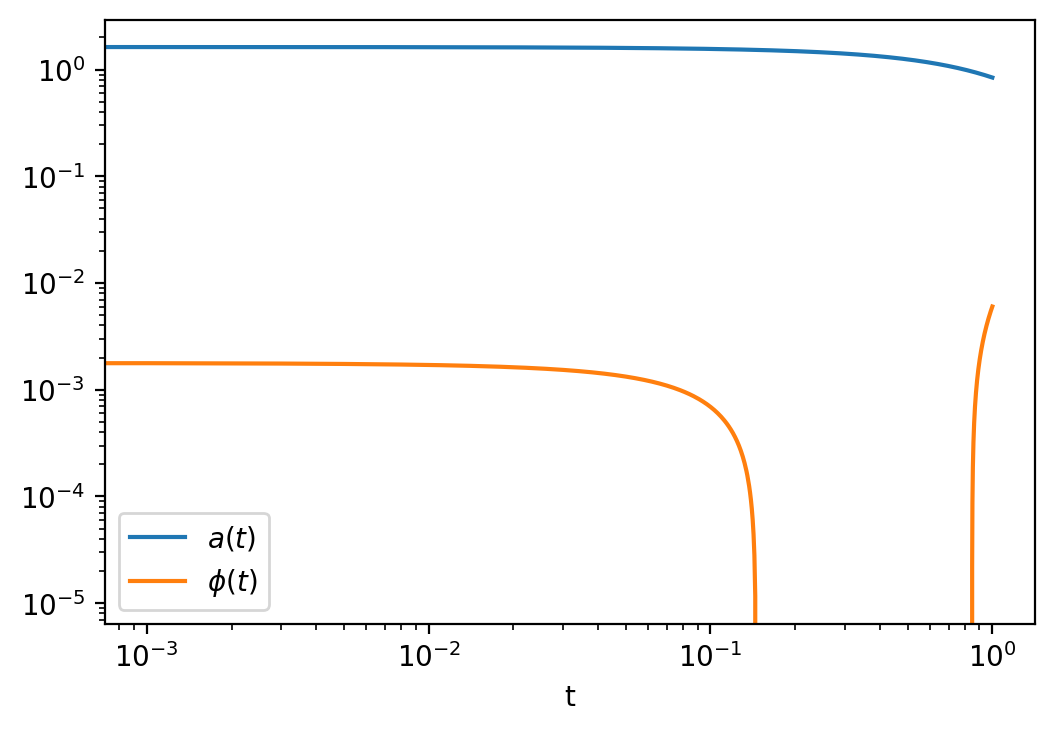

In [34]:
# Define the PINN model
class PINN(nn.Module):
    def __init__(self, num_layers, num_neurons):
        super(PINN, self).__init__()

        # Input layer
        self.layers = nn.ModuleList([nn.Linear(1, num_neurons)])

        # Hidden layers
        for _ in range(num_layers - 2):
            self.layers.append(nn.Linear(num_neurons, num_neurons))

        # Output layers (a and phidot)
        self.layers.append(nn.Linear(num_neurons, 2)) # Output: a(t), phidot(t)

    def forward(self, t):
        x = t
        for layer in self.layers[:-1]:
            x = torch.tanh(layer(x))
        x = self.layers[-1](x) # Last layer, no activation

        a = x[:, 0:1] # Scale factor
        phi = x[:,1:2] # Phi
        rho = x[:, 2:3] # Phi dot
        return a, phi, rho

# Define the physics-informed loss function
def physics_loss(net, t, ma, rho_m0, rho_r0, rho_l0):

    a, phi, rho = net(t)

    # Calculate derivatives using automatic differentiation
    a_t = torch.autograd.grad(a, t, grad_outputs=torch.ones_like(a), create_graph=True)[0]
    phi_t = torch.autograd.grad(phi, t, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
    phi_tt = torch.autograd.grad(phi_t, t, grad_outputs=torch.ones_like(phi_t), create_graph=True)[0]
    rho_t = torch.autograd.grad(rho, t, grad_outputs=torch.ones_like(rho), create_graph=True)[0]


    # Define the equations based on the image
    eq1 = a_t**2 -( (1/3) * (0.5*a**2*phi_t**2 + 0.5*ma**2*a**2*phi**2 + (rho_m0/a) + (rho_r0/a**2) +(rho_l0*a**2)) )
    eq2 = phi_tt - ( torch.sqrt(torch.tensor(3.0))*(torch.sqrt(0.5*(phi_t**2) + 0.5*ma**2*(phi**2) + (rho_m0/a**3) + (rho_r0/a**4) + (rho_l0))) )*phi_t+ ma**2*phi
    eq3 = rho_t + ( torch.sqrt(torch.tensor(3.0))*(torch.sqrt(0.5*(phi_t**2) + 0.5*ma**2*(phi**2) + (rho_m0/a**3) + (rho_r0/a**4) + (rho_l0))) )
                       
    # Calculate the residual (loss)
    loss_eq1 = torch.mean((eq1)**2)
    loss_eq2 = torch.mean((eq2)**2) 
    loss_eq3 = torch.mean((eq3)**2)

    return loss_eq1 + loss_eq2 + loss_eq3

# Define the initial condition loss
def initial_loss(net, t_ic, a_ic, phi_ic, rho_0):
    a_pred, phi_pred, rho_pred = net(t_ic)
    loss_a = torch.mean((a_pred - a_ic)**2)
    loss_phi = torch.mean((phi_pred - phi_ic)**2)
    loss_rho = torch.mean((rho_pred - rho_0))
    return loss_a + loss_phi + loss_rho

# Main training loop
def train_PINN(num_layers, num_neurons, ma, rho_m0, rho_r0, rho_l0,
                learning_rate, num_epochs, N_f,
                a_0, a_1, phi_0):  # Added a_0, a_1, phidot_0

    # Initialize the network
    net = PINN(num_layers, num_neurons)

    # Define the optimizer
    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate)

    # Generate training data
    t_f = torch.rand(N_f, 1, requires_grad=True)  # Random points for physics loss

    # Boundary conditions
    t_ic = torch.tensor([[0.0], [1.0]], requires_grad=False)  # Initial points
    a_ic = torch.tensor([[a_0], [a_1]], requires_grad=False)    # a(0) = 1e-8, a(1) = 1
    phi_ic = torch.tensor([[phi_0]], requires_grad=False) # phi(0) = 0


    # Training loop
    for epoch in range(num_epochs):
        optimizer.zero_grad()

        # Calculate the physics loss
        loss_physics = physics_loss(net, t_f, ma, rho_m0, rho_r0, rho_l0)

        # Calculate the boundary condition loss
        loss_ic = initial_loss(net, t_ic, a_ic, phi_ic[0:2], rho_0)


        # Combine the losses
        loss = loss_physics + loss_ic  # You may need to weight these losses

        # Backpropagation and optimization
        loss.backward()
        optimizer.step()

        # Print the loss every 100 epochs
        if (epoch+1) % 100 == 0:
            print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}, Physics Loss: {loss_physics.item():.6f}, IC Loss: {loss_ic.item():.6f}")

    return net

# --- Main execution ---
if __name__ == "__main__":

    # Define parameters
    num_layers = 3
    num_neurons = 128
    learning_rate = 1e-3
    num_epochs = 5000
    N_f = 10000     # Number of collocation points

    # initial condition values
    a_0 = 1e-8
    a_1 = 1.0
    phi_0 = phi_in
    rho_0 = rhoin_array

    # Train the PINN
    trained_net = train_PINN(num_layers, num_neurons, ma, rho_m0, rho_r0, rho_l0,
                             learning_rate, num_epochs, N_f,
                             a_0, a_1, phidot_0)

    # --- Plot the results ---
    # Generate test data
    t_test = torch.linspace(0, 1, 1000).reshape(-1, 1)

    # Make predictions
    with torch.no_grad():
        a_pred, phi_pred, rho_pred = trained_net(t_test)

    # Convert to NumPy arrays
    t_test = t_test.numpy()
    a_pred = a_pred.numpy()
    phi_pred = phi_pred.numpy()
    rho_pred = rho_pred.numpy()

    # Plot
    plt.figure(dpi=200)
    plt.plot(t_test, a_pred, label=r'$a(t)$')
    plt.plot(t_test, phi_pred, label=r'$\phi(t)$')
    plt.plot(t_test, rho_pred, label=r'$\rho(t)$')
    plt.xlabel('t')
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.show()



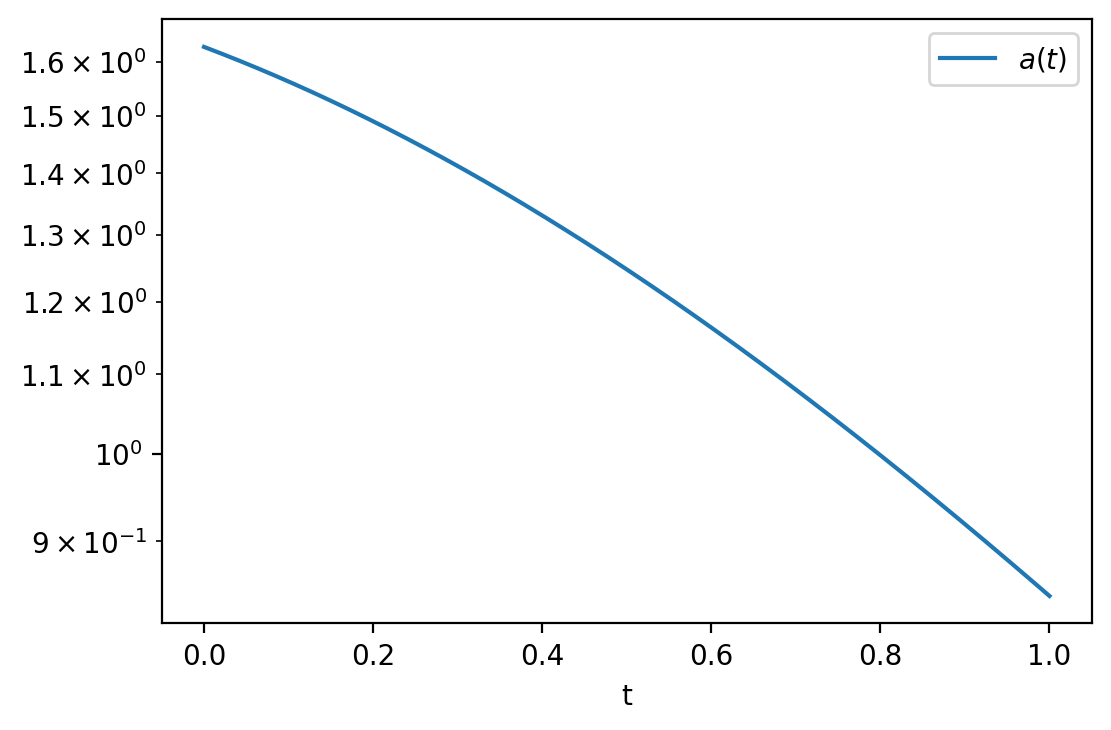

In [35]:
# Plot
plt.figure(dpi=200)
plt.plot(t_test, a_pred, label=r'$a(t)$')
# plt.plot(t_test, phi_pred, label=r'$\phi(t)$')
# plt.plot(t_test, rho_pred, label=r'$\rho(t)$')
plt.xlabel('t')
plt.yscale('log')
plt.legend()
plt.show()